# Train a custom spaCy NER model

## Introduction

Scope: Foundational entities. So we are considering all 9 test docs for this experiment.
- If we have a significant # of docs per category, and they're all quite different from each other, we might consider training a model per doc category

#### Step 1: Feature Engineering/Exploratory Analysis
1. Prepare Training Data
    - 80% of the foundational entity dataset, across 9 test docs
    - We need at least 200 examples (recommended by spaCy)

        ```python
    ['Page Number: 1. Page Title: Ashmore.', {'entities': [[28, 35, 'included_entities']]}],
    ```
2. Prepare Test Data
    - 20% of the foundational entity dataset, across 9 test docs
    - we look at performance here, because this assessess generalisability of our approach
3. Visualise entity category numbers in each set, for exploratory analysis

#### Step 2: Training and Evaluation
3. Train a spaCy ML model
4. Evaluate model performance across entity categories

These steps will be represented throughout this notebook

In [1]:
!pwd

/Users/nicoleramirez/Desktop/mantel/FutureFund/ff-azure-ner-poc/src/entity-recognition/spacy


# Step 1: Feature Engineering/Exploratory Analysis

Goal is to read all of the test documents, and combine their results into a big list, which we can use for train/test split

In [1]:
# import necessary libraries
import json
import spacy
import pandas as pd
import os

In [2]:
# read in 2x main files
RAW_TEXT_DIR="C:\\Users\\ramnic\\Desktop\\kmhub\\ff-azure-ner-poc\\docs\\raw_text_ocr\\ic_mrc_arc_large_batch" #raw OCR extracted text
ENTITIES_DIR="C:\\Users\\ramnic\\Desktop\\kmhub\\ff-azure-ner-poc\\docs\\extracted_entities\\ic_mrc_arc_large_batch" #raw entity labels

In [14]:
# clean entity labels
def clean_date_string(date_string):
    # Remove '[' and ']' characters
    cleaned = date_string.strip('[]')
    # Remove any escaped characters (e.g., \n, \t, etc.)
    cleaned = bytes(cleaned, 'utf-8').decode('unicode_escape')
    # Remove single or double quotes inside the string
    cleaned = cleaned.replace("'", "").replace('"', "")
    return cleaned

def clean_json(json_data, keys_to_remove):
    # Remove the specified keys
    for key in keys_to_remove:
        if key in json_data:
            del json_data[key]

    # Clean the values of any lists found in the JSON
    for key, value in json_data.items():
        # Check if the value is a list and contains strings
        if isinstance(value, list):
            json_data[key] = [clean_date_string(v) if isinstance(v, str) else v for v in value]

    return json_data

def process_files_in_directory(directory, keys_to_remove):
    # Loop through each file in the specified directory
    for filename in os.listdir(directory):
        # Check if the file is a JSON file
        if filename.endswith('.json'):
            file_path = os.path.join(directory, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)

                # Clean and remove the specified keys
                cleaned_data = clean_json(data, keys_to_remove)

                # Create a new filename with the '_cleaned' postfix
                new_filename = os.path.splitext(filename)[0] + '_cleaned.json'
                new_file_path = os.path.join(directory, new_filename)

                # Write the cleaned data to the new file
                with open(new_file_path, 'w', encoding='utf-8') as f:
                    json.dump(cleaned_data, f, indent=2)
                print(f"Processed and saved cleaned file: {new_filename}")

            except Exception as e:
                print(f"Failed to process {filename}: {e}")
                
keys_to_remove = ['dates', 'included entities']  # List of keys to remove
process_files_in_directory(ENTITIES_DIR, keys_to_remove)

Processed and saved cleaned file: response-01 - MRC - Action Item register 2024 (A1224500)-2025-02-14-18-09-37_cleaned.json
Processed and saved cleaned file: response-01 - MRC - Action Item register 2024 (A1224500)-2025-02-14-18-09-37_cleaned_cleaned.json
Processed and saved cleaned file: response-01 ARC - Decision item register 2024 (A1136154)-2025-02-14-18-09-51_cleaned.json
Processed and saved cleaned file: response-01 ARC - Decision item register 2024 (A1136154)-2025-02-14-18-09-51_cleaned_cleaned.json
Processed and saved cleaned file: response-01 IC - Action item register 2024 (A1108669)-2025-02-14-18-10-05_cleaned.json
Processed and saved cleaned file: response-01 IC - Action item register 2024 (A1108669)-2025-02-14-18-10-05_cleaned_cleaned.json
Processed and saved cleaned file: response-01 IC - Annual calendar 2024 (A1081726)-2025-02-14-18-10-31_cleaned.json
Processed and saved cleaned file: response-01 IC - Annual calendar 2024 (A1081726)-2025-02-14-18-10-31_cleaned_cleaned.jso

In [17]:
# read one cleaned file in to inspect
data = None
for filename in os.listdir(ENTITIES_DIR):
    if filename.endswith('_cleaned.json'):
        file_path = os.path.join(ENTITIES_DIR, filename)
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
            if data:
                # Check if the first key-value pair is not empty
                first_key = list(data.keys())[0]  # Get the first key
                first_value = data[first_key]     # Get the value of the first key
    
                # If the first value is not empty, print it and break the loop
                if first_value not in [None, "", '', [], {}, False]:
                    print(f"First key-value pair in {filename}: {first_key}: {first_value}")
                    print(data)
                    break

First key-value pair in response-01 - MRC - Action Item register 2024 (A1224500)-2025-02-14-18-09-37_cleaned.json: fund_managers: ['']
{'fund_managers': [''], 'investments': ['']}


In [24]:
# functions to read raw docs and entities with
def read_raw_docs(root_folder, extensions=['.txt']):
    """
    Reads files recursively from a root folder.
    
    :param root_folder: The root folder to start searching.
    :param extensions: Optional list of file extensions to filter (e.g., ['.txt', '.md']).
    """
    corpus = ''
    for dirpath, _, filenames in os.walk(root_folder):
        print(dirpath)
        for filename in filenames:
            print(filename)
            if extensions is None or any(filename.endswith(ext) for ext in extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        print(f"Reading {file_path}")
                        corpus += file.read()
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return corpus

def read_json_docs(root_folder, extensions=[".json"]):
    """
    Reads JSON files recursively from a root folder and merges their contents into a single dictionary,
    extending list values for shared keys.
    
    :param root_folder: The root folder to start searching.
    :param extensions: Optional list of file extensions to filter (default: ['.json']).
    :return: A dictionary containing the merged content of all JSON files.
    """
    if extensions is None:
        raise ValueError(f"no file extension provided. Can't read.")

    merged_dict = {}
    for dirpath, _, filenames in os.walk(root_folder):
        print(dirpath)
        for filename in filenames:
            if any(filename.endswith(ext) for ext in extensions):
                file_path = os.path.join(dirpath, filename)
                try:
                    with open(file_path, 'r', encoding='utf-8') as file:
                        if "_cleaned.json" in file_path:
                            print(f"Reading {file_path}")
                            file_content = json.load(file)
                            if not isinstance(file_content, dict) or not all(isinstance(v, list) for v in file_content.values()):
                                raise ValueError(f"Expected a dictionary with list values in {file_path}.")
                            for key, new_value in file_content.items():
                                if key in merged_dict:
                                    print(f"extending {key} with {new_value}")
                                    merged_dict[key].extend(new_value)  # Extend the list
                                    print(f"merged_dict[key] new: {merged_dict[key]}")
                                    pass
                                else:
                                    print(f"initialising: {key}")
                                    merged_dict[key] = new_value  # Add new key-value pair if it doesn't exist
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return merged_dict

In [25]:
# Usage
docs = read_raw_docs(RAW_TEXT_DIR)
entities = read_json_docs(ENTITIES_DIR)

C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mrc_arc_large_batch
01 - MRC - Action Item register 2024 (A1224500).txt
Reading C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mrc_arc_large_batch\01 - MRC - Action Item register 2024 (A1224500).txt
01 ARC - Decision item register 2024 (A1136154).txt
Reading C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mrc_arc_large_batch\01 ARC - Decision item register 2024 (A1136154).txt
01 IC - Action item register 2024 (A1108669).txt
Reading C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mrc_arc_large_batch\01 IC - Action item register 2024 (A1108669).txt
01 IC - Annual calendar 2024 (A1081726).txt
Reading C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mrc_arc_large_batch\01 IC - Annual calendar 2024 (A1081726).txt
ARC & MRC - 20241122 - Minutes (A604869) (A1230142).txt
Reading C:\Users\ramnic\Desktop\kmhub\ff-azure-ner-poc\docs\raw_text_ocr\ic_mr

In [26]:
# concatenate docs raw content and table content into a big string which would form our corpus
# docs = ' '.join(docs['textContent'] + docs['tableContent'])
print(docs[:500])

Action Items from Previous Meetings

Date



Action

Status Update/Due date

Owner



 





 NOTE: The MRC Action Item Register was created in November 2024 and does not capture actions from previous meetings










Completed action items

Date

Completed

Action

Owner






































































		A1108669	Confidential 	2

	A1108669                                                                       Confidential		                                 


In [27]:
# lets clean up \n characters
docs = docs.replace("\n", " ")

In [28]:
# print number of characters in corpus - spacy has to work with <1mil characters
print(f"number of characters in our corpus: {len(docs)}")

number of characters in our corpus: 5865897


In [32]:
# establish a dictionary of entity categories - for training spaCy custom NER later (per doc)
ent_patterns_list = [] # global scope
for ent_category, ent_list in entities.items():
    for ent in ent_list:
        # gets rid of empty entities
        if ent != '':
            ent_patterns_list.append(
                # {"label": ent_category, "pattern": [{"lower": ent}]}
                {"label": ent_category, "pattern": ent}
            )
print(ent_patterns_list[:10])

[{'label': 'fund_managers', 'pattern': 'OMERS'}, {'label': 'fund_managers', 'pattern': 'OMERS'}, {'label': 'fund_managers', 'pattern': 'Greystar Australia Pty Ltd'}, {'label': 'fund_managers', 'pattern': 'Greystar Australia Pty Ltd'}, {'label': 'investments', 'pattern': 'Transgrid'}, {'label': 'investments', 'pattern': 'OMERS'}, {'label': 'investments', 'pattern': 'Port of Melbourne'}, {'label': 'investments', 'pattern': 'Transgrid'}, {'label': 'investments', 'pattern': 'OMERS'}, {'label': 'investments', 'pattern': 'Port of Melbourne'}]


In [35]:
# spacy can only work with chunks <1mil characters at a time. chunk the corpus below
def divide_string_into_n_chunks(input_string, num_chunks):
    """
    Divides a string into `num_chunks` chunks and stores them in a dictionary.

    :param input_string: The string to be divided.
    :param num_chunks: The number of chunks.
    :return: A dictionary where the keys are indices, and the values are string chunks.
    """
    # Calculate the chunk size (integer division)
    chunk_size = len(input_string) // num_chunks
    remainder = len(input_string) % num_chunks
    
    # Dictionary to store chunks
    chunks_dict = {}
    start_index = 0

    for i in range(num_chunks):
        # Calculate the end index for the current chunk
        end_index = start_index + chunk_size + (1 if i < remainder else 0)  # Distribute remainder evenly
        chunks_dict[i] = input_string[start_index:end_index]
        start_index = end_index  # Update start index for next chunk
    
    return chunks_dict

# Example usage:
num_chunks = 6
doc_chunk_dict = divide_string_into_n_chunks(docs, num_chunks)


In [36]:
doc_chunk_dict

{0: 'Action Items from Previous Meetings  Date    Action  Status Update/Due date  Owner            NOTE: The MRC Action Item Register was created in November 2024 and does not capture actions from previous meetings           Completed action items  Date  Completed  Action  Owner                                                                       \t\tA1108669\tConfidential \t2  \tA1108669                                                                       Confidential\t\t                                                                 1                                                                                                        \tA1108669                                                                                                                              Confidential\t\t                                                                                                             1| ARC Decisions are noted in the Decision register.    | ARC Decisions are noted in the D

The below actually creates our training/testing dataset. Overall process:
- converts corpus to sentences
- creates annotation-entity spans

In [37]:
# create overall train-test dataset considering the chunks
TRAIN_TEST_DATASET = []
for _, chunk in doc_chunk_dict.items():
    nlp = spacy.load("en_core_web_sm") #m, lg, xl, tf
    nlp.add_pipe("sentencizer")

    # first chunk up the docs
    doc = nlp(chunk)

    corpus = []

    # into sentences
    for sent in doc.sents:
        corpus.append(sent.text)

    # re-initialise NLP pipeline to just have the entity ruler
    nlp = spacy.blank("en")
    ruler = nlp.add_pipe("entity_ruler")
    ruler.add_patterns(ent_patterns_list)

    # then chunk up the sentences
    for sentence in corpus:
        doc = nlp(sentence)
        train_test_entities = []

        # into entities
        for ent in doc.ents:
            train_test_entities.append([ent.start_char, ent.end_char, ent.label_]) 

        if len(train_test_entities) > 0: # post process to remove any items where entities list is empty
            TRAIN_TEST_DATASET.append([sentence, {"entities": train_test_entities}])
print(TRAIN_TEST_DATASET[:2])

[['The team responded:   Transgrid biggest energy infrastructure in Australia, which is expected to benefit from energy transition tailwinds, and derivative exposure to renewable energy build-out.   ', {'entities': [[22, 31, 'investments']]}], ['Capex risk is limited, given regulatory framework, noting Transgrid are at risk for material overruns  Large AUD asset, with high CPI performance over time with limited risk attached  Consistent with mandate to invest in Australian ventures that contribute to renewables build-out  ARC asked the team to describe the regulated framework of the investment and how Transgrid makes money in the regulatory structure.', {'entities': [[58, 67, 'investments'], [363, 372, 'investments']]}]]


In [39]:
print(f"number of items in our full train-test dataset: {len(TRAIN_TEST_DATASET)}")

number of items in our full train-test dataset: 370


In [40]:
# let's shuffle the data so we represent all parts of the document equally, not just the start in our training process

# Original data
import random

# Create a shuffled copy
shuffled_data = random.sample(TRAIN_TEST_DATASET, len(TRAIN_TEST_DATASET))

# Split into 80% for training and 20% for testing
split_index = int(0.8 * len(shuffled_data))
TRAIN_DATA = shuffled_data[:split_index]
TEST_DATA = shuffled_data[split_index:]

print("Original data unchanged:", TRAIN_TEST_DATASET)
print("Shuffled data:", shuffled_data)

Original data unchanged: [['The team responded:   Transgrid biggest energy infrastructure in Australia, which is expected to benefit from energy transition tailwinds, and derivative exposure to renewable energy build-out.   ', {'entities': [[22, 31, 'investments']]}], ['Capex risk is limited, given regulatory framework, noting Transgrid are at risk for material overruns  Large AUD asset, with high CPI performance over time with limited risk attached  Consistent with mandate to invest in Australian ventures that contribute to renewables build-out  ARC asked the team to describe the regulated framework of the investment and how Transgrid makes money in the regulatory structure.', {'entities': [[58, 67, 'investments'], [363, 372, 'investments']]}], ['PEC is a current project under construction by Transgrid and has suffered numerous setbacks, including delays and cost overruns.   ', {'entities': [[47, 56, 'investments']]}], ['The project may be subject to AER penalties, however we will exp

In [41]:
# print out # of senteces in train and test sets
print(f"# of elements in train data: {len(TRAIN_DATA)}")
print(f"# of elements in test data: {len(TEST_DATA)}")

# of elements in train data: 296
# of elements in test data: 74


In [6]:
# entity categories in train and test data

def count_entity_categories(data):
    result_dict, results_granular = {}, {}
    funds, fund_managers = set(), set()
    for sent, annotations in data:
        # print(annotations)
        for annot in annotations['entities']:
            ent = sent[annot[0]:annot[1]]
            ent_category = annot[2]
            if ent_category not in result_dict:
                result_dict[ent_category] = 1
            else:
                # print(f"ent category: {ent_category} has count: {result_dict[ent_category]}")
                result_dict[ent_category] += 1
            if ent_category == 'investments':
                funds.add(ent)
            elif ent_category == 'fund_managers':
                fund_managers.add(ent)
    results_granular["investments"] = funds
    results_granular["fund_managers"] = fund_managers
    return result_dict, results_granular

print(f"Training dataset (number of entities):")
train_analysis, train_ds_granular = count_entity_categories(TRAIN_DATA)
print(train_analysis)
print(f"Testing dataset (number of entities):")
test_analysis, test_ds_granular = count_entity_categories(TEST_DATA)
print(test_analysis)

Training dataset (number of entities):
{'investments': 355, 'fund_managers': 54}
Testing dataset (number of entities):
{'investments': 83, 'fund_managers': 21}


In [7]:
# duplicates considered
print(f"Training dataset (number of entities - duplicates incl):")
print(train_analysis)
print(f"Testing dataset (number of entities - duplicates incl):")
print(test_analysis)

Training dataset (number of entities - duplicates incl):
{'investments': 355, 'fund_managers': 54}
Testing dataset (number of entities - duplicates incl):
{'investments': 83, 'fund_managers': 21}


In [8]:
# unique ents considered
print(f"Training dataset (number of entities unique):")
print(f"funds: {len(train_ds_granular["investments"])}, fund managers: {len(set(train_ds_granular["fund_managers"]))}")
print(f"Testing dataset (number of entities unique):")
print(f"funds: {len(set(test_ds_granular["investments"]))}, fund managers: {len(set(test_ds_granular["fund_managers"]))}")

Training dataset (number of entities unique):
funds: 11, fund managers: 2
Testing dataset (number of entities unique):
funds: 9, fund managers: 2


In [43]:
# saving train and test data to pickle files
import pickle

with open('TRAIN-ic-mrc-arc-large-batch.pkl', 'wb') as train_file:
    pickle.dump(TRAIN_DATA, train_file)

with open('TEST-ic-mrc-arc-large-batch.pkl', 'wb') as test_file:
    pickle.dump(TEST_DATA, test_file)

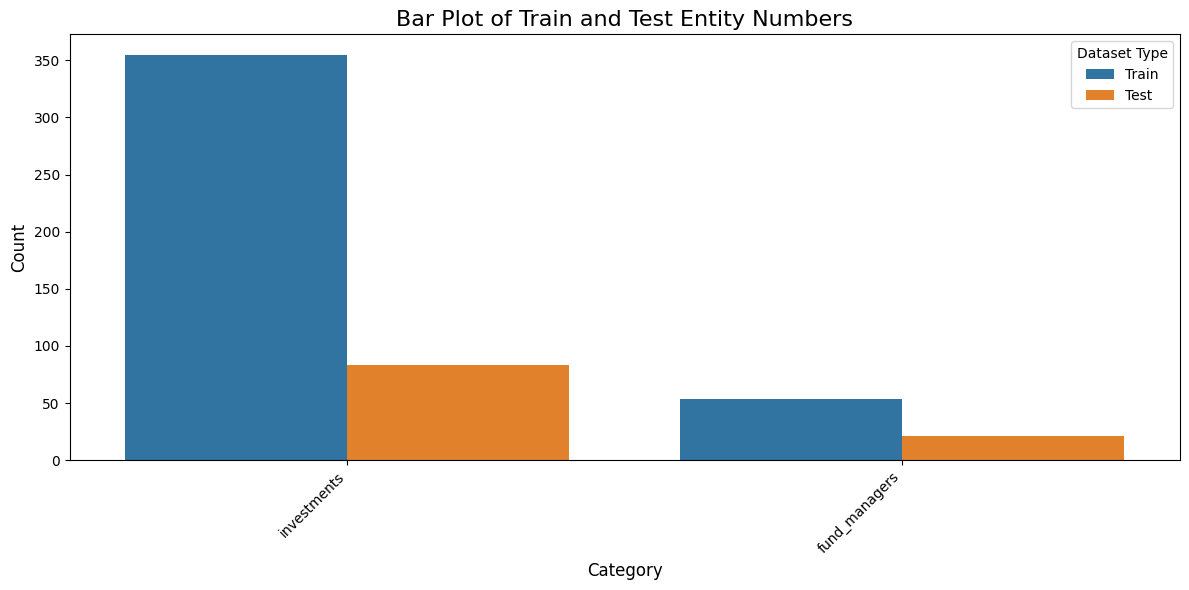

In [44]:
# plot our numer of train-test entities to get an idea of what entity categories the model will learn really well

import seaborn as sns 
import matplotlib.pyplot as plt

# Convert dictionaries into a DataFrame for plotting
train_df = pd.DataFrame({'Category': train_analysis.keys(), 'Count': train_analysis.values(), 'Type': 'Train'})
test_df = pd.DataFrame({'Category': test_analysis.keys(), 'Count': test_analysis.values(), 'Type': 'Test'})

# Combine the dataframes
combined_df = pd.concat([train_df, test_df])

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=combined_df, x='Category', y='Count', hue='Type')

# Enhance the plot
plt.title('Bar Plot of Train and Test Entity Numbers', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Dataset Type', fontsize=10)
plt.tight_layout()

# Show the plot
plt.show()

# Step 2: Train a spaCy custom named entity recognizer (NER)

### Training

In [45]:
from spacy.tokens import DocBin

In [46]:
# we first have to binarise our train and test datasets into .spacy files each (train.spacy, valid.spacy)
db = DocBin()
nlp = spacy.load("en_core_web_sm") #small, medium, large, xl, tf/BERT architecture
for text, annotations in TRAIN_DATA:
    entity_annotations = annotations['entities']
    for annotation in entity_annotations:
        doc = nlp(text)
        ents = []
        start, end, label = annotation
        span = doc.char_span(start, end, label=label)
        ents.append(span)
        doc.ents = ents
        print(f"text: {text}, ents: {ents}")
        db.add(doc)
db.to_disk("./train.spacy")

db = DocBin()
nlp = spacy.load("en_core_web_sm")
for text, annotations in TEST_DATA:
    entity_annotations = annotations['entities']
    for annotation in entity_annotations:
        doc = nlp(text)
        ents = []
        start, end, label = annotation
        span = doc.char_span(start, end, label=label)
        ents.append(span)
        doc.ents = ents
        print(f"text: {text}, ents: {ents}")
        db.add(doc)
db.to_disk("./valid.spacy")

text: Zinfra has been leveraging State Grid's procurement scale and relationships to deliver projects on time and at a lower cost., ents: [Zinfra]
text: Zinfra has been leveraging State Grid's procurement scale and relationships to deliver projects on time and at a lower cost., ents: [State Grid]
text: The team are also familiar with OMERS team because they have board representation on Port of Melbourne.    , ents: [OMERS]
text: The team are also familiar with OMERS team because they have board representation on Port of Melbourne.    , ents: [Port of Melbourne]
text: GIP management team will co-invest 1% alongside the GIPA II fund investment (A$7m in total and A$2.2m for FF/MRP's pro-rata share), and has a right to sell their coinvestments to investors via a put option in year 10 based on prevailing independent valuations.  , ents: [GIPA II]
text: - 3.72 Figure 23 details the aggregated RAB of the business across both the electric and gas regulated businesses  <!-- image -->  Source:  

In [23]:
# this CLI command feeds in the binarised training and testing files to train and eval the spacy model with
# --output specifies where to output the best performing model and associated artefacts
# try the below in a terminal if it can't run in jupyter notebook
!python -m spacy train config.cfg --output ./output --paths.train ./train.spacy --paths.dev ./valid.spacy

C:\ProgramData\anaconda3\python.exe: No module named spacy


## Evaluation

In [1]:
import pickle

In [2]:
import spacy
from spacy.training.example import Example

In [4]:
with open("TEST-ic-mrc-arc-large-batch.pkl", "rb") as f:
    TEST_DATA = pickle.load(f)

with open("TRAIN-ic-mrc-arc-large-batch.pkl", "rb") as f:
    TRAIN_DATA = pickle.load(f)

In [35]:
# load the best performing model from the output directory (directory specified by --output kwarg above)
trained_model = spacy.load("output/model-best")
examples = []
for text, annots in TEST_DATA:
    doc = trained_model.make_doc(text)
    examples.append(Example.from_dict(doc, annots))
test_performance_dict = trained_model.evaluate(examples) # evaluate the best performing model's performance on test data

In [36]:
# load the best performing model from the output directory (directory specified by --output kwarg above)
train_examples = []
for text, annots in TRAIN_DATA:
    doc = trained_model.make_doc(text)
    examples.append(Example.from_dict(doc, annots))
train_performance_dict = trained_model.evaluate(examples) # evaluate the best performing model's performance on test data

In [37]:
# output of evaluation is a dictionary containing overall vs entity category specific precision, recall and f1 score
test_performance_dict

{'token_acc': 1.0,
 'token_p': 1.0,
 'token_r': 1.0,
 'token_f': 1.0,
 'ents_p': 0.9506172839506173,
 'ents_r': 0.7403846153846154,
 'ents_f': 0.8324324324324324,
 'ents_per_type': {'investments': {'p': 0.9565217391304348,
   'r': 0.7951807228915663,
   'f': 0.868421052631579},
  'fund_managers': {'p': 0.9166666666666666,
   'r': 0.5238095238095238,
   'f': 0.6666666666666667}},
 'speed': 7838.073374989395}

In [38]:
# below is for training performance - expecting close to 100%
train_performance_dict

{'token_acc': 1.0,
 'token_p': 1.0,
 'token_r': 1.0,
 'token_f': 1.0,
 'ents_p': 0.9818181818181818,
 'ents_r': 0.7368421052631579,
 'ents_f': 0.8418708240534521,
 'ents_per_type': {'investments': {'p': 0.987987987987988,
   'r': 0.7511415525114156,
   'f': 0.853437094682231},
  'fund_managers': {'p': 0.9423076923076923,
   'r': 0.6533333333333333,
   'f': 0.7716535433070866}},
 'speed': 7364.705527963276}

We plot the `test_performance_dict` for better visualisation below

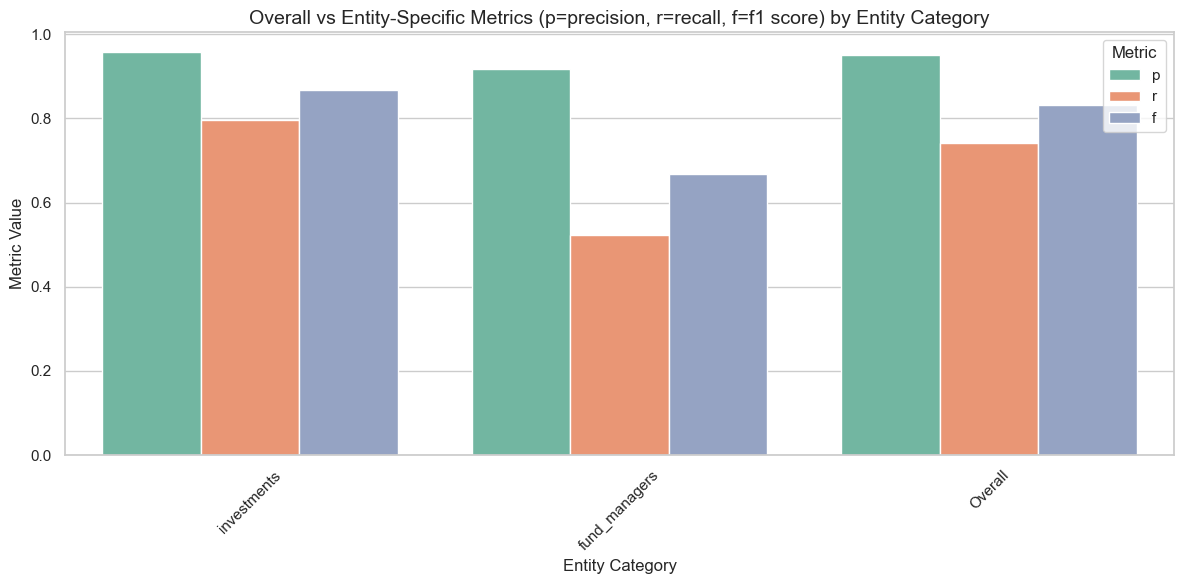

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = test_performance_dict

# Extract the overall metrics
overall_metrics = {
    'p': data['ents_p'],
    'r': data['ents_r'],
    'f': data['ents_f']
}

# Extract the entity-specific metrics
entity_metrics = data['ents_per_type']

# Convert the data to a DataFrame for easier plotting
entity_categories = list(entity_metrics.keys())
entity_p = [entity_metrics[ent]['p'] for ent in entity_categories]
entity_r = [entity_metrics[ent]['r'] for ent in entity_categories]
entity_f = [entity_metrics[ent]['f'] for ent in entity_categories]

# Create a DataFrame for entity-specific metrics in long format
df_entity = pd.DataFrame({
    'Entity Category': entity_categories * 3,  # Repeating the entity categories for each metric (p, r, f)
    'Metric': ['p'] * len(entity_categories) + ['r'] * len(entity_categories) + ['f'] * len(entity_categories),
    'Value': entity_p + entity_r + entity_f
})

# Create a DataFrame for overall metrics (one row for each metric)
df_overall = pd.DataFrame({
    'Entity Category': ['Overall'] * 3,
    'Metric': ['p', 'r', 'f'],
    'Value': [overall_metrics['p'], overall_metrics['r'], overall_metrics['f']]
})

# Concatenate the entity-specific and overall metrics
df_combined = pd.concat([df_entity, df_overall], ignore_index=True)

# Set up the plot
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Plot the bars
sns.barplot(x="Entity Category", y="Value", hue="Metric", data=df_combined, palette="Set2")

# Customize the plot
plt.title("Overall vs Entity-Specific Metrics (p=precision, r=recall, f=f1 score) by Entity Category", fontsize=14)
plt.xlabel("Entity Category", fontsize=12)
plt.ylabel("Metric Value", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metric", loc="upper right")

# Show the plot
plt.tight_layout()
plt.show()

### A note on ML metrics

- **precision** - % correct entities/tags that are retrieved from a sentence
- **recall** - % entities attributed to the correct word(s) from a sentence
- **f1 score** - the harmonic mean of both precision and recall

for eg, the sentence `The S&P 500 is a well-performing fund`. If our true entity is the `S&P500` and its entity category is `fund`:
- **precision** will correctly identify that there is a `fund` entity there, but _can_ misattribute it to another word (picks up false positives)
- **recall** will correctly attribute `fund` to `S&P500`
- up to the business to determine which one suits, we can argue that `precision` is enough for a KMS. When you're tagging chunks of data, you'd just need to know some 'fund' information is in that data chunk

### Inference

In [40]:
# feed in a random document chunk to the trained model for inference
result = trained_model(doc_chunk_dict[3][1000:])

NameError: name 'doc_chunk_dict' is not defined

In [42]:
# inference pipeline of many sentences
test_inference = []
for text, _ in TEST_DATA:
    result = trained_model(text)
    test_inference.append({
        'sentence': text,
        'ents': [(ent.text, ent.label_) for ent in result.ents]}) # many ents in them

In [43]:
test_inference

[{'sentence': '| Powerlink -25% and Others - 5%) assumed to be below historical market share  achieved by Zinfra.                                                                                                                     ',
  'ents': [('Zinfra', 'investments')]},
 {'sentence': "In addition to the FF Base Case, Table 3 below presents the look forward equity IRR's and equity values for the GIP NBIO Case, the Vendor Reserve Price, the Vendor Case and: - i) FF Downside Case:  assumes a lower inflation forecast, remaining at 2.0% in the long-term, lower gas markets contracting with no PKET revenue and worse market share outcome for Zinfra. - ii) FF Upside Case:   assumes a slower transition and longer lives of regulated gas assets, higher utilisation of the gas transmission pipelines, higher  inflation consistent with FF ECM's Ruptures forecast (long term 3.5%), and corresponding high interest rates (long term base rate of 5.5%).  ",
  'ents': [('Zinfra', 'investments')]},
 {'sente

In [68]:
# the below are some utilities to populate random colours for distinct entity groups
# Dictionary to store entity label to hex color mapping
import random

label_to_color = {}

# Function to generate a random hex color
def generate_random_color():
    return "#{:06x}".format(random.randint(0, 0xFFFFFF))

# Iterate over entities
for ent in result.ents:
    # If the label is not in the dictionary, assign a random color
    if ent.label_ not in label_to_color:
        label_to_color[ent.label_] = generate_random_color()

# Print the dictionary
print("Entity label to color mapping:")
for label, color in label_to_color.items():
    print(f"{label}: {color}")

Entity label to color mapping:
investments: #2d7495


In [69]:
# the below actually displays the entities tagged during inference
options = {"ents": [entity_category for entity_category, _ in label_to_color.items()], "colors": label_to_color} 
spacy.displacy.render(result, style="ent", jupyter=True, options=options)

#### Inference analysis

In [44]:
investments, fund_managers = set(), set()
for inference_item in test_inference:
    for ent in inference_item['ents']:
        if ent[1] == "investments":
            investments.add(ent[0])
        elif ent[1] == "fund_managers":
            fund_managers.add(ent[0])

In [45]:
investments

{'GIPA II',
 'Greystar Australia Pty',
 'Greystar Project Tropics',
 'Jemena',
 'OMERS',
 'State Grid',
 'Transgrid',
 'Zinfra'}

In [46]:
fund_managers

{'OMERS'}

### Inference on new chunks of documents

In [47]:
# read doc 
example_1 = """
ARC decision: The Asset Review Committee unanimously approved (those eligible to vote KML not voting) that, subject to the satisfactory completion of due diligence, the negotiation of transaction documents and any necessary approvals of relevant Board subsidiaries, and final approval by the Agency; i.	an investment of up to A$300m, plus any transaction/manager related fees and expenses capped at A$2m, into Canva, comprising A$270m from Future Fund and A$30m from Medical Research Future Fund Return Pool; ii.	the appointment by Medical Research Future Fund Return Pool of Quadrant or their relevant group entities as investment manager for its investment in Canva on terms consistent with those described in this paper; and iii.	the appointment by Future Fund of Quadrant or their relevant group entities as investment manager for its investment in Canva on terms consistent with those described in this paper.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
|                  2 | 2024-04-02 00:00:00    | Project Sunrise (Circular resolution)  | JW, JFS, KP, AW, MD | ARC decision: The Asset Review Committee unanimously approved (those eligible to vote JW, JFS, MG not voting) that, subject to the satisfactory completion by the Agency of due diligence and final negotions of transaction documents,  '- an investment in respect of the Future Fund for up to A$575m to acquire an interest of up to 18% in Eastlink, subject to a minimum expected internal rate of return of 9.0% pa (nominal, post-tax and fees); and - an investment in respect of the Medical Research Future Fund Return Pool for up to A$65m to acquire an interest of up to 2.0% in EastLink, subject to a minimum expected IRR of 9
"""

In [48]:
example_2 = """
The session began with the Team providing a brief overview of the investment:

US$200m (FF/MRP: US$170/30m) co-investment opportunity with EQT VI in a fiber-to-the-home (FTTH) joint venture with T-Mobile (TMO).

Noted that FF has previously invested in EQT-IV and has received board and IC approval for co-investments alongside EQT.

This would be the first co-investment with EQT. 

TMO is one of the largest telecommunications and wireless network operators in the US, with a market cap of c.US$195bn. 

The reason for the new venture comes from TMO’s desire to increase exposure to the fibre broadband network to complement their existing
"""

In [49]:
a

In [50]:
print(get_entities_fr_text(example_2))

[]


# Rules-based matching and ML matching in a pipeline

In [51]:
# first load in the funds and fund managers, in sets (so there are no duplicates)
import pickle
import pandas as pd
import os 

In [52]:
# manager reference - 2nd tab: FUND_MANAGER, INVESTMENT_NAME_LEGAL
# fundmaster - first tab: Fund Name, Fund Manager
# combine both
data_folder = 'matching_data'

df_0 = pd.read_excel(os.path.join(data_folder, 'FundMaster.xlsx'), sheet_name=0)
# df_1 = pd.read_excel(os.path.join(data_folder, 'Manager reference.xlsx'), sheet_name="fund_manager_funds")

In [53]:
df_0 = pd.read_excel(os.path.join(data_folder, 'FundMaster.xlsx'), sheet_name=0)
# df_1 = pd.read_excel(os.path.join(data_folder, 'Manager reference.xlsx'), sheet_name="fund_manager_funds")

fund_managers, funds = set(), set()

In [54]:
df_0.head()

,Fund Name,Fund Manager,Type,NT Account,Asset Class,BNP_INSTR_ID
0,FRM Argyle Limited - Class A FRM Equity Alpha ...,Man Solutions Limited,1,FFB551,Alternatives,BNPINSTR_0000192943
1,Bridgewater Pure Alpha Fund III Ltd,Bridgewater Associates Ltd,1,FFB554,Alternatives,BNPINSTR_0000192653
2,Citadel Kensington Global Strategies Fund II Ltd,Citadel Advisors LLC,FUND,FFB565,Alternatives,BNPINSTR_0000192805
3,"Atom Overseas Ltd - Class A-AUD Shares, Sub-Cl...",Atom Investors LP,FUND,FFB568,Alternatives,BNPINSTR_0000193122
4,Dymon Asia Multi-Strategy Investment Fund,Dymon Asia Capital,FUND,FFB569,Alternatives,BNPINSTR_0000192957


In [55]:
funds.update(df_0['Fund Name'].unique().tolist())
fund_managers.update(df_0['Fund Manager'].unique().tolist())

In [56]:
len(funds), len(fund_managers)

(941, 188)

todo:
- try rule-based pipeline first, match it on the inference set and see if any are picked out
- then match on whole doc set
- then incorporate ML
(1.5 hours)

In [57]:
# inference dataset
with open("TEST-ic-mrc-arc-large-batch.pkl", "rb") as f:
    TEST_DATA = pickle.load(f)

In [58]:
TEST_DATA[:2]

[['| Powerlink -25% and Others - 5%) assumed to be below historical market share  achieved by Zinfra.                                                                                                                     ',
  {'entities': [[91, 97, 'investments']]}],
 ["In addition to the FF Base Case, Table 3 below presents the look forward equity IRR's and equity values for the GIP NBIO Case, the Vendor Reserve Price, the Vendor Case and: - i) FF Downside Case:  assumes a lower inflation forecast, remaining at 2.0% in the long-term, lower gas markets contracting with no PKET revenue and worse market share outcome for Zinfra. - ii) FF Upside Case:   assumes a slower transition and longer lives of regulated gas assets, higher utilisation of the gas transmission pipelines, higher  inflation consistent with FF ECM's Ruptures forecast (long term 3.5%), and corresponding high interest rates (long term base rate of 5.5%).  ",
  {'entities': [[356, 362, 'investments']]}]]

In [248]:
# load the best performing model from the output directory (directory specified by --output kwarg above)
trained_model = spacy.load("output/model-best")

In [249]:
print(f"current components of my spacy pipeline: {trained_model.pipe_names}")

current components of my spacy pipeline: ['tok2vec', 'ner']


In [68]:
# # Remove the entity_ruler component
# trained_model.remove_pipe("entity_ruler")

# # Verify that it's been removed
# print(trained_model.pipe_names)

['tok2vec', 'ner']


In [250]:
# UTILITIES FUNCTIONS
# function for printing quantities and info in results dict
def print_results_content(results_dict: dict) -> None:
    print(f"""
    # of fund_managers unique: {len(set(results_dict["fund_managers"]))}
    # of fund_managers duplicate: {len(results_dict["fund_managers"])}
    # of funds unique: {len(set(results_dict["investments"]))}
    # of funds duplicate: {len(results_dict["investments"])}
    """)

def get_aggregate_inference() -> dict:
    """
    Assumes a pipeline component has been added/removed.
    Gets inference results with that change included.
    """
    results_dict = {}
    for text, _ in TRAIN_DATA + TEST_DATA:
        ents_list = get_entities_fr_text(text)
        for ent in ents_list:
            ent, ent_category = ent[0], ent[1]
            if ent_category not in results_dict:
                results_dict[ent_category] = [ent]
            else:
                results_dict[ent_category].append(ent)
    return results_dict

In [253]:
# before adding entity ruler, quantify inference on train test data:
before_eruler_results = get_aggregate_inference()

print("ML Model (NER) only")
print(print_results_content(before_eruler_results))

ML Model (NER) only

    # of fund_managers unique: 3
    # of fund_managers duplicate: 52
    # of funds unique: 9
    # of funds duplicate: 333
    
None


In [254]:
# add ent ruler, and quantify
from spacy.pipeline import EntityRuler

# Add the EntityRuler component before the 'ner' component
entity_ruler = trained_model.add_pipe("entity_ruler", before="ner")

patterns = [{"label": "investments", "pattern": fund} for fund in funds] + \
[{"label": "fund_managers", "pattern": fund} for fund in fund_managers]

# Add patterns to the entity ruler
entity_ruler.add_patterns(patterns)

print(f"nlp pipeline components: {trained_model.pipe_names}")

nlp pipeline components: ['tok2vec', 'entity_ruler', 'ner']


In [255]:
# quantify
# after entity ruler, quantify inference on train test data:
add_eruler_before_ner = get_aggregate_inference()

print("Adding an entityRuler for exact matching before NER model:")
print(print_results_content(add_eruler_before_ner))
# doc = nlp("John Doe works at OpenAI.")
# print([(ent.text, ent.label_) for ent in doc.ents])
# ruler = EntityRuler(trained_model, overwrite_ents=True)
# for term in funds:
#     ruler.add_patterns([{"label": "investments", "pattern": term}])  # Add rule-based entity

#     # Add the EntityRuler to the pipeline before NER
# trained_model.add_pipe(ruler, before="ner")

Adding an entityRuler for exact matching before NER model:

    # of fund_managers unique: 4
    # of fund_managers duplicate: 73
    # of funds unique: 7
    # of funds duplicate: 325
    
None


In [256]:
# add ent ruler after, and don't overwrite ents
# reason being NER populates ents itself. We want to merge results instead

trained_model.remove_pipe('entity_ruler')

# Add the EntityRuler component before the 'ner' component
entity_ruler = trained_model.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": False})

patterns = [{"label": "investments", "pattern": fund} for fund in funds] + \
[{"label": "fund_managers", "pattern": fund} for fund in fund_managers]

# Add patterns to the entity ruler
entity_ruler.add_patterns(patterns)

print(f"nlp pipeline components: {trained_model.pipe_names}")

nlp pipeline components: ['tok2vec', 'ner', 'entity_ruler']


In [257]:
# quantify the results after adding entity ruler after ner, without overwrite
add_eruler_after_ner = get_aggregate_inference()

print("Adding entityRuler for exact matching after NER model")
print(print_results_content(add_eruler_after_ner))

Adding entityRuler for exact matching after NER model

    # of fund_managers unique: 6
    # of fund_managers duplicate: 65
    # of funds unique: 9
    # of funds duplicate: 333
    
None


In [258]:
# add to UTILITIES
def create_pattern(text: str) -> list:
    try:
        tokens = text.split()
        # Even if there's only one token, we still return a list of dictionaries.
        return [{"LOWER": str.lower(token)} for token in tokens]
    except:
        pass

In [259]:
# now let's do case-insensitive matching, adding ent ruler after ner
trained_model.remove_pipe('entity_ruler')

# Add the EntityRuler component before the 'ner' component
entity_ruler = trained_model.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": False})

patterns = [{"label": "investments", "pattern": create_pattern(fund)} for fund in funds] + \
[{"label": "fund_managers", "pattern": create_pattern(fund_mgr)} for fund_mgr in fund_managers]

# Add patterns to the entity ruler
entity_ruler.add_patterns(patterns)

print(f"nlp pipeline components: {trained_model.pipe_names}")

nlp pipeline components: ['tok2vec', 'ner', 'entity_ruler']


In [260]:
# quantify the results after adding entity ruler after ner, without overwrite and with lowercasing
add_eruler_after_ner_lowercase = get_aggregate_inference()

print("Adding entityRuler (lowercasing exact match) after NER model:")
print(print_results_content(add_eruler_after_ner_lowercase))

Adding entityRuler (lowercasing exact match) after NER model:

    # of fund_managers unique: 7
    # of fund_managers duplicate: 70
    # of funds unique: 9
    # of funds duplicate: 333
    
None


In [261]:
# now lets tokenise everything, so that we match tokens (singly) -- 
# TOO MANY RANDOM TOKENS that will add noise (ive tried and mistakenly deleted my code. all good
# add to UTILITIES
def create_fuzzy_pattern(text: str) -> list:
    try:
        # Even if there's only one token, we still return a list of dictionaries.
        return [{"LOWER": {"FUZZY" : str.lower(text)}}]
    except:
        pass

In [262]:
# now let's do case-insensitive matching, adding ent ruler after ner
trained_model.remove_pipe('entity_ruler')

# Add the EntityRuler component before the 'ner' component
entity_ruler = trained_model.add_pipe("entity_ruler", after="ner", config={"overwrite_ents": False})

patterns = [{"label": "investments", "pattern": create_fuzzy_pattern(fund)} for fund in funds] + \
[{"label": "fund_managers", "pattern": create_fuzzy_pattern(fund_mgr)} for fund_mgr in fund_managers]

# Add patterns to the entity ruler
entity_ruler.add_patterns(patterns)

print(f"nlp pipeline components: {trained_model.pipe_names}")

nlp pipeline components: ['tok2vec', 'ner', 'entity_ruler']


In [263]:
# quantify the results after adding entity ruler after ner, without overwrite and with lowercasing and fuzzy matching
add_eruler_after_ner_lowercase_fuzzy_match = get_aggregate_inference()

print("Adding entityRuler (lowercasing and fuzzy matching) after NER model:")
print(print_results_content(add_eruler_after_ner_lowercase_fuzzy_match))

Adding entityRuler (lowercasing and fuzzy matching) after NER model:

    # of fund_managers unique: 175
    # of fund_managers duplicate: 1600
    # of funds unique: 9
    # of funds duplicate: 333
    
None


In [226]:
set(add_eruler_after_ner_lowercase_fuzzy_match['fund_managers'])

{"'s",
 'APA',
 'APG',
 'ARC',
 'ART',
 'AUS',
 'As',
 'Aus',
 'BASE',
 'BC',
 'Base',
 'C$',
 'CASE',
 'CEFC',
 'CEO',
 'CFO',
 'CGS',
 'CIM',
 'CKI',
 'CPA',
 'CPA2',
 'CPAs',
 'CPI',
 'Cap',
 'Case',
 'Co',
 'Core',
 'D',
 'DB',
 'DDP',
 'Date',
 'ECD',
 'Farm',
 'Gas',
 'Greystar',
 'Greystar Australia Pty Ltd  \t\t\t',
 'Greystar Australia Pty Ltd is managed',
 'Hill',
 'IC',
 'INFRASTRUCTURE',
 'Infrastructure',
 'It',
 'Its',
 'JW',
 'Kate',
 'Kd',
 'LLC',
 'LPs',
 'LT',
 'Large',
 'Late',
 'Laws',
 'MAR',
 'MD',
 'MPAs',
 'MRC',
 'More',
 'NAR',
 'NPS',
 'Name',
 'OMERS',
 'PEC',
 'PRE',
 'PWC',
 'Pac',
 'Partners',
 'PwC',
 'QIC',
 'RAB',
 'RFR',
 'RRs',
 'Rate',
 'Role',
 'Sale',
 'Same',
 'TAC',
 'TARP',
 'That',
 'Two',
 'UI&T',
 'US',
 'VIC',
 'Vic',
 'Vint',
 'WH',
 'We',
 'add',
 'apa',
 'apart',
 'are',
 'arm',
 'as',
 'aware',
 'base',
 'blackout',
 'bps',
 'built',
 'c',
 'c.',
 'can',
 'cap',
 'case',
 'co',
 'coinvestments',
 'core',
 'date',
 'day',
 'days',
 'de',

In [229]:
# now, lets remove the NER component and just have the entity ruler component:
# now let's do case-insensitive matching, adding ent ruler after ner
# trained_model.remove_pipe('ner')
print(f"nlp pipeline components: {trained_model.pipe_names}")

nlp pipeline components: ['tok2vec', 'entity_ruler']


In [233]:
# quantify the results after adding entity ruler after ner, without overwrite and with lowercasing and fuzzy matching
eruler_only = get_aggregate_inference()

print("entityRuler only")
eruler_only.keys()

entityRuler only


dict_keys(['fund_managers'])

In [246]:
print(f"With just the entity matcher fuzzy matching:")
print(f"""
# of fund managers (unique): {len(set(eruler_only['fund_managers']))}
# of fund managers (duplicates): {len(eruler_only['fund_managers'])}
""")
# a lot of errors there

With just the entity matcher fuzzy matching:

# of fund managers (unique): 172
# of fund managers (duplicates): 1565



In [237]:
# add to utilities later
def extract_entities(data):
    # Initialize a dictionary to hold the labels and corresponding entities
    entities_dict = {'investments': [], 'fund_managers': []}
    
    # Loop over the data list
    for text, annotations in data:
        # Loop over the entities in the 'entities' list within annotations
        for start, end, label in annotations['entities']:
            # Extract the entity from the text using the start and end indices
            entity = text[start:end]
            
            # Check if the label is one of the specified ones and append the entity
            if label in entities_dict:
                entities_dict[label].append(entity)
    
    return entities_dict

baseline_entities_train_test = extract_entities(TRAIN_DATA + TEST_DATA)

In [245]:
print(f"Before model training - LLM identified, in our train test set:")
print(f"""
num of fund managers baseline (unique): {len(set(baseline_entities_train_test['fund_managers']))}
num of fund managers baseline (duplicates): {len(baseline_entities_train_test['fund_managers'])}
num of funds baseline (unique): {len(set(baseline_entities_train_test['investments']))}
num of funds baseline (duplicates): {len(baseline_entities_train_test['investments'])}
""")

Before model training - LLM identified, in our train test set:

num of fund managers baseline (unique): 2
num of fund managers baseline (duplicates): 75
num of funds baseline (unique): 11
num of funds baseline (duplicates): 438



# Debugging/Investigation Section

In [116]:
for pattern in trained_model.get_pipe("entity_ruler").patterns:
    print(pattern)

{'label': 'investments', 'pattern': [{'LOWER': 'Ares'}, {'LOWER': 'Credit'}, {'LOWER': 'Strategies'}, {'LOWER': 'Feeder'}, {'LOWER': 'Fund'}, {'LOWER': 'III,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'Berkshire'}, {'LOWER': 'Bridge'}, {'LOWER': 'Loan'}, {'LOWER': 'III,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'BAA'}, {'LOWER': 'Freycinet'}, {'LOWER': 'Fund'}, {'LOWER': 'Core'}, {'LOWER': '-'}, {'LOWER': 'Taula'}, {'LOWER': 'Global'}, {'LOWER': 'Macro'}, {'LOWER': 'Limited'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'North'}, {'LOWER': 'Haven'}, {'LOWER': 'Real'}, {'LOWER': 'Estate'}, {'LOWER': 'Fund'}, {'LOWER': 'IX'}, {'LOWER': 'Global-F,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'Hillwood'}, {'LOWER': 'US'}, {'LOWER': 'Industrial'}, {'LOWER': 'Club'}, {'LOWER': 'VI,'}, {'LOWER': 'LP'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'TowerBrook'}, {'LOWER': 'Investors'}, {'LOWER': 'IV'}, {'LOW

In [119]:
trained_model.pipe_names

['tok2vec', 'ner', 'entity_ruler']

In [142]:
# test

# Create a test NLP pipeline with just EntityRuler
test_nlp = spacy.blank("en")
ruler = test_nlp.add_pipe("entity_ruler")
# test one - pulling bakc
patterns = [{"label": "investments", "pattern": [{"LOWER": "DWS"}]}]
# patterns = [{"label": "investments", "pattern": create_pattern(fund)} for fund in funds] + \
# [{"label": "fund_managers", "pattern": create_pattern(fund_mgr)} for fund_mgr in fund_managers]

# Add patterns to the entity ruler
ruler.add_patterns(patterns)

In [143]:
min_pattern_entry = min(test_nlp.get_pipe('entity_ruler').patterns, key=lambda x: len(x['pattern']))

# Print the result
print(min_pattern_entry)

{'label': 'investments', 'pattern': [{'LOWER': 'DWS'}]}


In [147]:
test_nlp.analyze_pipes()

{'summary': {'entity_ruler': {'assigns': ['doc.ents',
    'token.ent_type',
    'token.ent_iob'],
   'requires': [],
   'scores': ['ents_f', 'ents_p', 'ents_r', 'ents_per_type'],
   'retokenizes': False}},
 'problems': {'entity_ruler': []},
 'attrs': {'doc.ents': {'assigns': ['entity_ruler'], 'requires': []},
  'token.ent_type': {'assigns': ['entity_ruler'], 'requires': []},
  'token.ent_iob': {'assigns': ['entity_ruler'], 'requires': []}}}

In [146]:
doc = test_nlp("i have DWS investments")
print(doc.ents)  # Debugging output

()


In [151]:
test_nlp.pipe_names

['entity_ruler']

In [148]:
doc = test_nlp("i have DWS investments")
for token in doc:
    print(f"Token: {token.text}, Ent Type: {token.ent_type_}, Ent IOB: {token.ent_iob_}")

Token: i, Ent Type: , Ent IOB: O
Token: have, Ent Type: , Ent IOB: O
Token: DWS, Ent Type: , Ent IOB: O
Token: investments, Ent Type: , Ent IOB: O


In [150]:
doc = test_nlp("i have DWS investments")
for token in doc:
    print(f"Text: {token.text}, Lower: {token.lower_}, Shape: {token.shape_}")

Text: i, Lower: i, Shape: x
Text: have, Lower: have, Shape: xxxx
Text: DWS, Lower: dws, Shape: XXX
Text: investments, Lower: investments, Shape: xxxx


In [149]:
min_pattern_entry = min(test_nlp.get_pipe('entity_ruler').patterns, key=lambda x: len(x['pattern']))

# Print the result
print(min_pattern_entry)

{'label': 'investments', 'pattern': [{'LOWER': 'DWS'}]}


In [139]:
doc = test_nlp("i have DWS investments")
for token in doc:
    print(token.text, token.lower_, token.shape_)

i i x
have have xxxx
DWS dws XXX
investments investments xxxx


In [188]:
test_nlp = spacy.blank("en")
_ = test_nlp.add_pipe("entity_ruler")
entity_ruler = test_nlp.get_pipe("entity_ruler")

# Explicitly add the pattern again
entity_ruler.add_patterns([{"label": "fund_managers", "pattern": [{"LOWER": "dws"}, {"LOWER": "beta"}]}])
entity_ruler.add_patterns([{"label": "fund_managers", "pattern": [{"LOWER": "hongshan"}]}])


# Test the detection again
doc = test_nlp("i have beta and HonGShan investments")
print([(ent.text, ent.label_) for ent in doc.ents])  # Should detect 'DWS' as 'fund_managers'

[('HonGShan', 'fund_managers')]


conclusion:
- patterns in "LOWER" truly have to be lowercased
- patterns are treated left --> right. If a pattern "DWS" "beta" is provided, and only DWS is in text, it will match DWS. If only beta is in text, it wont match beta. If DWS Beta is in text, it will match both

In [131]:
from spacy import displacy

doc = test_nlp("i have DWS investments")
displacy.render(doc, style="ent", jupyter=True)  # Shows entities in a Jupyter notebook

C:\Users\ramnic\ic_mrc_arc_funds_fund_managers\.venvpy312\Lib\site-packages\spacy\displacy\__init__.py:213: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


In [120]:
#Property'}, {'LOWER': 'Sunk'}, {'LOWER': 'Cost'}]}
#[(ent.text, ent.label_) for ent in result.ents]
test_result = trained_model("i have HongShan investments")
print(test_result.ents)

()


In [108]:
# inspect entity ruler's patterns
for pattern in entity_ruler.patterns:
    print(pattern)

{'label': 'investments', 'pattern': [{'LOWER': 'Ares'}, {'LOWER': 'Credit'}, {'LOWER': 'Strategies'}, {'LOWER': 'Feeder'}, {'LOWER': 'Fund'}, {'LOWER': 'III,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'Berkshire'}, {'LOWER': 'Bridge'}, {'LOWER': 'Loan'}, {'LOWER': 'III,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'BAA'}, {'LOWER': 'Freycinet'}, {'LOWER': 'Fund'}, {'LOWER': 'Core'}, {'LOWER': '-'}, {'LOWER': 'Taula'}, {'LOWER': 'Global'}, {'LOWER': 'Macro'}, {'LOWER': 'Limited'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'North'}, {'LOWER': 'Haven'}, {'LOWER': 'Real'}, {'LOWER': 'Estate'}, {'LOWER': 'Fund'}, {'LOWER': 'IX'}, {'LOWER': 'Global-F,'}, {'LOWER': 'L.P.'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'Hillwood'}, {'LOWER': 'US'}, {'LOWER': 'Industrial'}, {'LOWER': 'Club'}, {'LOWER': 'VI,'}, {'LOWER': 'LP'}]}
{'label': 'investments', 'pattern': [{'LOWER': 'TowerBrook'}, {'LOWER': 'Investors'}, {'LOWER': 'IV'}, {'LOW

In [ ]:
# now let's do statistical matching



In [37]:
# below is chatgpt's recommendation also (note - combines trained model and rule-based matcher)import spacy
from spacy.pipeline import EntityRuler
from spacy.matcher import Matcher
from spacy.tokens import Span

# Load a trained SpaCy model with NER (replace with your own model if needed)
nlp = spacy.load("en_core_web_md")  # Use 'en_core_web_trf' for better accuracy

# Define a set of target terms for rule-based matching
target_set = {"apple", "banana", "orange"}

# Create an EntityRuler and add patterns for exact matching
ruler = EntityRuler(nlp, overwrite_ents=True)
for term in target_set:
    ruler.add_patterns([{"label": "FRUIT", "pattern": term}])  # Add rule-based entity

# Add the EntityRuler to the pipeline before NER
nlp.add_pipe(ruler, before="ner")

# Create a Matcher object
matcher = Matcher(nlp.vocab)

# Function to add patterns based on lowercase matching
def add_patterns_to_matcher(matcher, target_set):
    for term in target_set:
        pattern = [{"lower": term}]  # Match lowercase word
        matcher.add(term, [pattern])

# Add exact-match patterns
add_patterns_to_matcher(matcher, target_set)

# Custom component for similarity-based matching
def similarity_matcher(doc):
    matches = matcher(doc)
    new_ents = list(doc.ents)  # Keep existing entities from the model

    for match_id, start, end in matches:
        span = doc[start:end]  # Get the matched span
        new_ents.append(Span(doc, start, end, label="FRUIT"))  # Assign entity label

    # Word vector similarity-based matching
    for token in doc:
        for term in target_set:
            term_token = nlp(term)[0]  # Convert term to a SpaCy token
            if token.similarity(term_token) > 0.75:  # Similarity threshold
                new_ents.append(Span(doc, token.i, token.i + 1, label="FRUIT"))

    # Assign new entities to the document
    doc.ents = new_ents
    return doc

# Add the custom similarity matcher after the NER component
nlp.add_pipe(similarity_matcher, after="ner")

# Process text
doc = nlp("I love eating apples and bananas. The tangelo was juicy.")

# Print detected entities
print([(ent.text, ent.label_) for ent in doc.ents])


In [ ]:
# Loaded the trained NER Model
nlp = spacy.load("my_spacy_model")

# Define entity patterns for EntityRuler (just showing 2 relevant patterns here, it contains more patterns)
patterns = [{"label": "GENE", "pattern": "BRCA1"},
            {"label": "GENE", "pattern": "BRCA2"}]

ruler = EntityRuler(nlp)

ruler.add_patterns(patterns)

nlp.add_pipe(ruler, before="ner") #allows you to prioritise rule-based matcher vs NER matcher

# Aside: Basic spaCy (basic NER) entity tagging

### Using prebuilt/basic model for inference

on entire TRAIN_TEST_DATASET

In [ ]:
# get a flattened list of entities
flattened_list = []
for category, entity_list in entities.items():
    for entity in entity_list:
        if entity != '':
            flattened_list.append(entity)
print(flattened_list[:2])

['Modern Slavery Act Statement by Breville Group Limited & Subsidiaries', 'MODERN SLAVERY STATEMENT']


In [30]:
# the below loads a small spacy model for basic NER, and actually performs basic NER on our WHOLE train-test-dataset

# Initialize spaCy model
nlp = spacy.load("en_core_web_sm") #m, lg, xl, transformer versions

# Function to find context, entity, and position
def extract_basic_entity_context(data, content, n_words=3):
    doc = nlp(content)
    result = []

    # For each entity in 'data'
    for entity in list(set(data)):
        # Find matches of the entity in the content
        for match in doc.ents:
            if entity.lower() in match.text.lower():  # Matching entity case-insensitively
                start, end = match.start, match.end
                
                # Get the n words flanking the entity
                start_idx = max(start - n_words, 0)  # Ensure we don't go out of bounds
                end_idx = min(end + n_words, len(doc))  # Ensure we don't go out of bounds
                
                # Get the context (flanking words)
                context = " ".join([token.text for token in doc[start_idx:end_idx]])

                # Position of the entity in the text
                position = (start, end)

                # Collect the match key (this is an example of match.key())
                match_key = match.label_  # or any other identifier you want to use

                # Append the information to the result list
                result.append({
                    'context': context,
                    'entity': match.text,
                    'entity_desc': spacy.explain(match_key),
                    'position': position,
                    'entity_category': match_key
                })

    return result

# Running the function - better to have in a for loop, but keeping here for experimentation
extracted_data_basic = extract_basic_entity_context(flattened_list, doc_chunk_dict[0])
extracted_data_basic_2 = extract_basic_entity_context(flattened_list, doc_chunk_dict[1])

In [31]:
# put the results in a df so we can visualise results
basic_ner_df = pd.DataFrame(extracted_data_basic)

In [32]:
basic_ner_df.head()

,context,entity,entity_desc,position,entity_category
0,% stake in Northern Indiana Public Services Co...,Northern Indiana Public Services Company LLC,"Companies, agencies, institutions, etc.","(74194, 74200)",ORG
1,""" ) , Indiana 's largest electric",Indiana,"Countries, cities, states","(74206, 74207)",GPE
2,5 Japan 6 South Korea 6 Taiwan 6,South Korea,"Countries, cities, states","(43206, 43208)",GPE
3,being provided for Blackstone Inc. ( together ...,Blackstone Inc.,"Companies, agencies, institutions, etc.","(71048, 71050)",ORG
4,"expectations . For Blackstone Inc. , such risks",Blackstone Inc.,"Companies, agencies, institutions, etc.","(75362, 75364)",ORG


spacy's basic NER model predicts entity categories that aren't an exact match to what we want. We therefore have to create a mapping between our desired entities and spacy's if we want to evaluate the basic model:

- document_name - `WORK_OF_ART`, `LAW`
- reporting_entity - `NORP`, `ORG`
- included_entities - `NORP`, `ORG`, `EVENT`, `PRODUCT`
- company_identifiers - some picked up in `ORG`
- registered_addresses - `N/A`
- phone_numbers - `N/A`
- people_roles - just people - `PERSON`
- reporting_period - `DATE`, `CARDINAL`
- geographies - `LOC`, `FAC`, `GPE`, `NORP`
- currencies - `MONEY`

In [61]:
# mapping from our custom entities to basic ones picked up by spacy prebuilt models
custom_to_basic = {
    'document_name': ['WORK_OF_ART', 'LAW'],
    'reporting_entity': ['NORP', 'ORG'],
    'included_entities': ['NORP', 'ORG', 'EVENT', 'PRODUCT'],
    'company_identifiers': ['ORG'],
    'registered_addresses': [],
    'phone_numbers': [],
    'people_roles': ['PERSON'],
    'reporting_period': ['DATE', 'CARDINAL'],
    'geographies': ['LOC', 'FAC', 'GPE', 'NORP'],
    'currencies': ['MONEY']
}

In [ ]:
# the resulting dataframe showing basic NER entities picked up, their description
basic_ner_df.groupby(['entity_category', 'entity_desc'])['entity'].apply(list)

entity_category  entity_desc                                         
CARDINAL         Numerals that do not fall under another type            [2023/2024, 2023, 2023, 2023, 2023, 2023, 2023...
DATE             Absolute or relative dates or periods                   [30 June 2024, 2024, 30 June 2024, 2024, 2024,...
EVENT            Named hurricanes, battles, wars, sports events, etc.    [the Santos Code of Conduct, the Paris Agreement]
FAC              Buildings, airports, highways, bridges, etc.            [Vector Metering, Norway UAE, Berkeley Square ...
GPE              Countries, cities, states                               [Canberra, Netherlands, Endua, Endua, Solomon ...
LAW              Named documents made into laws.                         [Semis 9 Real Estate 6 Industrials Communicati...
LOC              Non-GPE locations, mountain ranges, bodies of water     [Europe, Europe, Europe, Europe, Europe, Europ...
MONEY            Monetary values, including unit                     

Saving the actual results to a file below for inspection:

In [63]:
basic_ner_df.groupby(['entity_category', 'entity_desc'])['entity'].apply(list).reset_index().to_csv('entity_basic_inspection.csv')

Results of basic entity tagging

In [64]:
counts_basic_entity_ner = basic_ner_df.groupby('entity_category').count()['context'].reset_index().rename(columns={'context': 'counts'})

counts_basic_entity_ner

,entity_category,counts
0,CARDINAL,130
1,DATE,445
2,EVENT,2
3,FAC,10
4,GPE,326
5,LAW,6
6,LOC,61
7,MONEY,9
8,NORP,80
9,ORG,2419
